# Week 7 — Nodes, Edges & Conditional Routing

## Learning Goals

- Understand normal edges
- Understand conditional edges
- Create routing functions
- Dynamically choose the next node
- Understand how this applies to AI agents

In [1]:
from typing import TypedDict

from langgraph.graph import StateGraph, START, END

class State(TypedDict):
    question: str
    complexity: str
    answer: str

In [2]:
def planner_node(state: State):
    question = state["question"].lower()

    complex_keywords = [
        "compare",
        "explain",
        "advantages",
        "disadvantages",
        "research",
        "analyze",
    ]

    if any(keyword in question for keyword in complex_keywords):
        complexity = "complex"
    else:
        complexity = "simple"

    print(f"Question: {state['question']}")
    print(f"Complexity: {complexity}")

    return {
        "complexity": complexity
    }

In [5]:
def simple_answer_node(state: State):
    print("Simple answer node running...")

    return {
        "answer": f"Simple answer for: {state['question']}"
    }

In [6]:
def research_node(state: State):
    print("Research node running...")

    return {
        "answer": f"Research completed for: {state['question']}"
    }

In [7]:
graph = StateGraph(State)

graph.add_node("planner", planner_node)
graph.add_node("simple_answer", simple_answer_node)
graph.add_node("research", research_node)

graph.add_edge(START, "planner")

In [8]:
def route_question(state: State):
    if state["complexity"] == "complex":
        return "research"

    return "simple_answer"

In [9]:
graph.add_conditional_edges(
    "planner",
    route_question
)

graph.add_edge("simple_answer", END)
graph.add_edge("research", END)

In [11]:
app = graph.compile()
result = app.invoke({
    "question": "Compare React Native and Flutter",
    "complexity": "",
    "answer": ""
})

result

Question: Compare React Native and Flutter
Complexity: complex
Research node running...


{'question': 'Compare React Native and Flutter',
 'complexity': 'complex',
 'answer': 'Research completed for: Compare React Native and Flutter'}

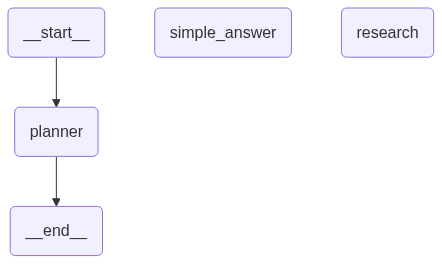

In [12]:
from IPython.display import Image, display

display(
    Image(
        app.get_graph().draw_mermaid_png()
    )
)